In [3]:
# ============================================================
# Import Libraries
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from lightgbm import LGBMRegressor

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# Load the datasets
# ============================================================

train = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")

In [5]:
# Display the dimensions of each dataset

print(f"Train:    {train.shape}")
print(f"Stores:   {stores.shape}")
print(f"Features: {features.shape}")

Train:    (421570, 5)
Stores:   (45, 3)
Features: (8190, 12)


In [6]:
# Preview each dataset

display(train.head())

display(stores.head())

display(features.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [7]:
# Examine the schema of each dataset

train.info()

stores.info()

features.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 17.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-nul

In [8]:
# Count missing values

print("Train")
display(train.isnull().sum().to_frame("Missing Values"))

print("Stores")
display(stores.isnull().sum().to_frame("Missing Values"))

print("Features")
display(features.isnull().sum().to_frame("Missing Values"))

Train


,Missing Values
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


Stores


,Missing Values
Store,0
Type,0
Size,0


Features


,Missing Values
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


#### Merge and Prepare the Data

The forecasting model requires information from all three datasets:

- **train.csv** contains the target variable (`Weekly_Sales`).
- **stores.csv** adds store-level attributes such as type and size.
- **features.csv** provides external factors that may influence sales, including holidays, weather, fuel prices, and markdown events.

We'll merge these datasets into a single table that can be used for analysis and model development.

In [9]:
# ============================================================
# Merge the datasets
# ============================================================

# Merge train and store information
df = train.merge(
    stores,
    on="Store",
    how="left"
)

# Merge external features
df = df.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

print(f"Final dataset shape: {df.shape}")

Final dataset shape: (421570, 16)


In [10]:
# Preview the merged dataset
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [11]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [12]:
# Convert Date to datetime

df["Date"] = pd.to_datetime(df["Date"])

In [13]:
# Sort chronologically

df = (
    df
    .sort_values(["Store", "Dept", "Date"])
    .reset_index(drop=True)
)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

In [15]:
# Missing values by column

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing[missing["Missing Values"] > 0]

,Missing Values
MarkDown2,310322
MarkDown4,286603
MarkDown3,284479
MarkDown1,270889
MarkDown5,270138


### Observations

Most variables have complete data, but the `MarkDown1` through `MarkDown5` columns contain a large number of missing values.

This is expected. Markdown promotions were introduced later in the historical period covered by the dataset, so many earlier records do not have associated markdown values. These missing values reflect business operations rather than data collection errors.

In the next section, we'll decide how to handle these missing values before building our forecasting model.

### Data Cleaning

Before exploring the data or training a forecasting model, it's important to ensure the dataset is clean and consistent.

In this section, we'll:

- Handle missing values
- Verify there are no duplicate records
- Check for invalid values
- Prepare the dataset for analysis

In [16]:
# Percentage of missing values

missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("Missing (%)")
)

missing_pct[missing_pct["Missing (%)"] > 0]

,Missing (%)
MarkDown2,73.611025
MarkDown4,67.984676
MarkDown3,67.480845
MarkDown1,64.257181
MarkDown5,64.079038


In [17]:
# Fill missing markdown values with 0

markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [18]:
# Fill remaining numeric missing values with the median

numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [19]:
# Confirm that all missing values have been handled

df.isnull().sum().sort_values(ascending=False).head(10)

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
dtype: int64

In [21]:
print(f"Start Date : {df['Date'].min().date()}")
print(f"End Date   : {df['Date'].max().date()}")

Start Date : 2010-02-05
End Date   : 2012-10-26


In [22]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 421,570
Columns : 16


### Summary

The dataset is now ready for exploratory analysis.

We've:

- Merged all three data sources into a single modeling table.
- Handled missing values.
- Verified there are no duplicate records.
- Confirmed the historical date range.

With a clean dataset in place, we can now explore sales trends, seasonality, holiday effects, and other patterns that will inform our forecasting model.

In [23]:
# Preserve a clean version for analysis and modeling

df_clean = df.copy()

### Exploratory Data Analysis

Before building a forecasting model, it's important to understand how sales change over time.

In this section, we'll explore:

- Overall sales trends
- Seasonal patterns
- Holiday effects
- Differences across stores
- Relationships between sales and external factors

These insights will guide our feature engineering and model selection.

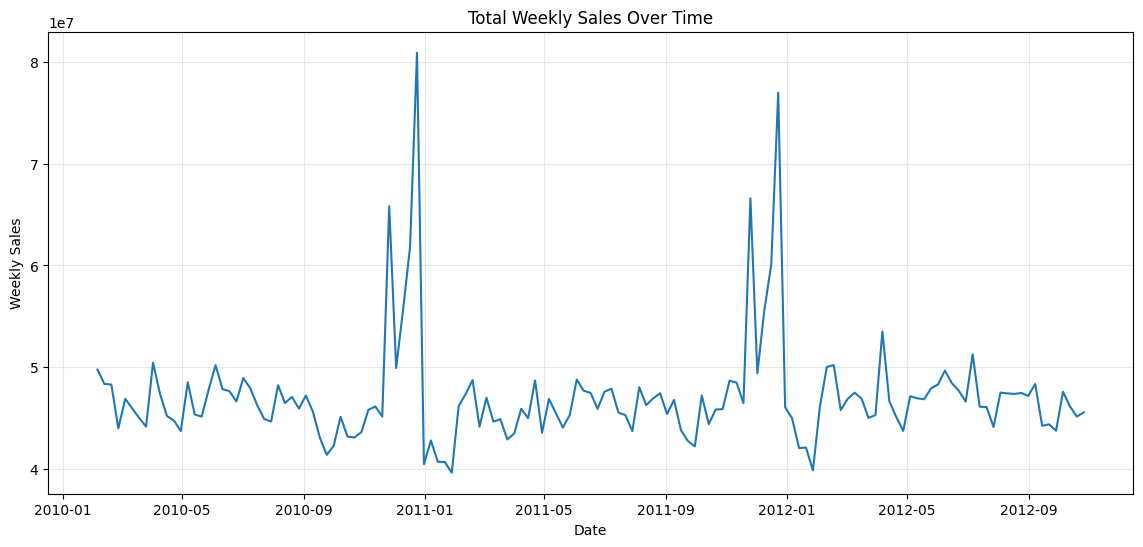

In [24]:
# Aggregate weekly sales across all stores and departments
weekly_sales = (
    df_clean.groupby("Date")["Weekly_Sales"]
            .sum()
            .reset_index()
)

plt.figure(figsize=(14,6))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(alpha=0.3)
plt.show()

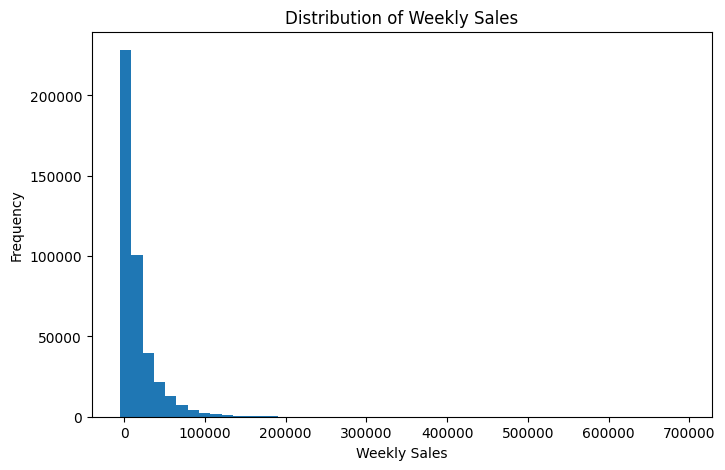

In [25]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [26]:
holiday_sales = (
    df_clean.groupby("IsHoliday")["Weekly_Sales"]
            .mean()
)

holiday_sales

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

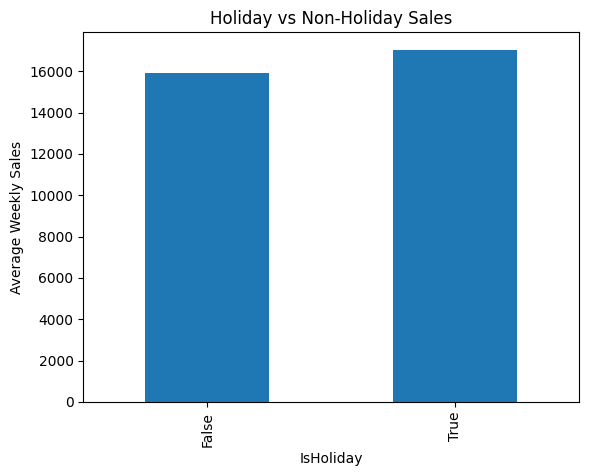

In [27]:
holiday_sales.plot(kind="bar")
plt.ylabel("Average Weekly Sales")
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

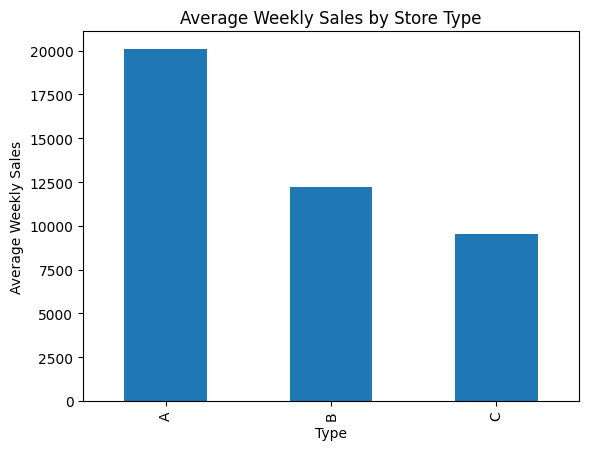

In [28]:
store_sales = (
    df_clean.groupby("Type")["Weekly_Sales"]
            .mean()
)

store_sales.plot(kind="bar")
plt.ylabel("Average Weekly Sales")
plt.title("Average Weekly Sales by Store Type")
plt.show()

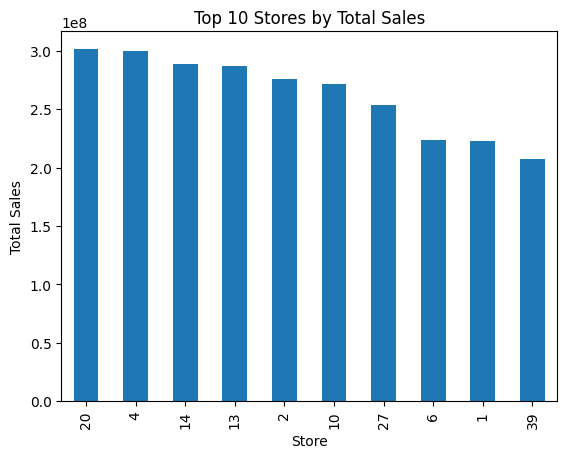

In [29]:
top_stores = (
    df_clean.groupby("Store")["Weekly_Sales"]
            .sum()
            .sort_values(ascending=False)
            .head(10)
)

top_stores.plot(kind="bar")
plt.title("Top 10 Stores by Total Sales")
plt.ylabel("Total Sales")
plt.show()

In [30]:
numeric_cols = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

corr = df_clean[numeric_cols].corr()

corr

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,-0.002312,-0.000120,-0.020921,-0.025864
Temperature,-0.002312,1.000000,0.143859,0.182112,0.096730
Fuel_Price,-0.000120,0.143859,1.000000,-0.164210,-0.033853
CPI,-0.020921,0.182112,-0.164210,1.000000,-0.299953
Unemployment,-0.025864,0.096730,-0.033853,-0.299953,1.000000


In [31]:
holiday_trend = (
    df_clean.groupby(["Date","IsHoliday"])["Weekly_Sales"]
            .sum()
            .reset_index()
)

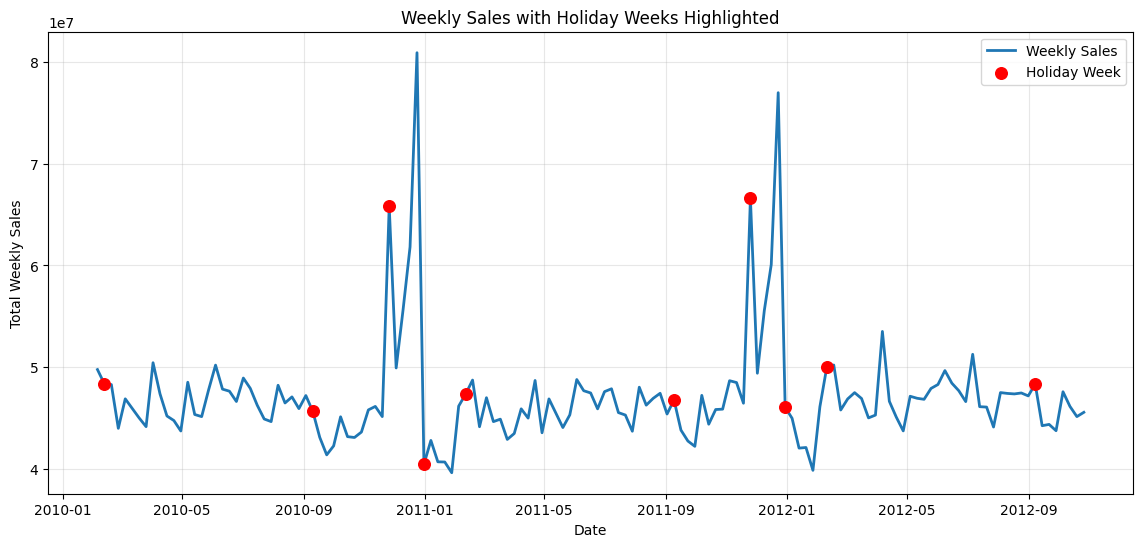

In [32]:
# ============================================================
# Weekly Sales During Holiday Weeks
# ============================================================

# Aggregate weekly sales across all stores and departments
weekly_sales = (
    df_clean.groupby(["Date", "IsHoliday"])["Weekly_Sales"]
            .sum()
            .reset_index()
)

plt.figure(figsize=(14, 6))

# Plot overall weekly sales
plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    linewidth=2,
    label="Weekly Sales"
)

# Highlight holiday weeks
holiday_weeks = weekly_sales[weekly_sales["IsHoliday"]]

plt.scatter(
    holiday_weeks["Date"],
    holiday_weeks["Weekly_Sales"],
    color="red",
    s=70,
    label="Holiday Week",
    zorder=3
)

plt.title("Weekly Sales with Holiday Weeks Highlighted")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Key Observations

- Sales exhibit clear seasonal patterns with pronounced spikes during holiday periods.
- Weekly sales are highly right-skewed, with a small number of observations accounting for very large sales volumes.
- Holiday weeks tend to generate higher average sales than non-holiday weeks.
- Sales vary considerably across store types, suggesting that store characteristics may improve forecasting accuracy.
- External variables such as temperature and unemployment show relatively weak linear relationships with sales, although they may still provide predictive value when combined with other features.

### Feature Engineering

Machine learning models cannot infer temporal patterns directly from dates. Instead, we create features that capture historical behavior, seasonality, and external influences.

In this section, we'll engineer features that help the model learn from:

- Calendar information
- Past sales
- Recent sales trends
- Store characteristics
- External factors

In [33]:
# ============================================================
# Calendar Features
# ============================================================

df_model = df_clean.copy()

df_model["Year"] = df_model["Date"].dt.year
df_model["Month"] = df_model["Date"].dt.month
df_model["Week"] = df_model["Date"].dt.isocalendar().week.astype(int)
df_model["Quarter"] = df_model["Date"].dt.quarter

# Optional but useful
df_model["Is_Month_Start"] = df_model["Date"].dt.is_month_start.astype(int)
df_model["Is_Month_End"] = df_model["Date"].dt.is_month_end.astype(int)

In [34]:
# ============================================================
# Lag Features
# ============================================================

lags = [1, 2, 4, 13, 52]

for lag in lags:
    df_model[f"Lag_{lag}"] = (
        df_model
        .groupby(["Store", "Dept"])["Weekly_Sales"]
        .shift(lag)
    )

In [35]:
# ============================================================
# Rolling Statistics
# ============================================================

df_model["Rolling_Mean_4"] = (
    df_model
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

df_model["Rolling_Mean_8"] = (
    df_model
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

df_model["Rolling_Std_4"] = (
    df_model
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(lambda x: x.shift(1).rolling(4).std())
)

In [36]:
# ============================================================
# Encode Categorical Variables
# ============================================================

categorical_cols = ["Store", "Dept", "Type"]

for col in categorical_cols:
    df_model[col] = df_model[col].astype("category")

In [37]:
# Drop rows with insufficient history

df_model = df_model.dropna().reset_index(drop=True)

In [38]:
print(df_model.shape)

df_model.head()

(261083, 30)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Quarter,Is_Month_Start,Is_Month_End,Lag_1,Lag_2,Lag_4,Lag_13,Lag_52,Rolling_Mean_4,Rolling_Mean_8,Rolling_Std_4
0,1,1,2011-02-04,21665.76,False,A,151315,42.27,2.989,0.0,0.0,0.0,0.0,0.0,212.566881,7.742,2011,2,5,1,0,0,18461.18,17341.47,15984.24,34238.88,24924.50,17286.6475,27576.61375,1013.925386
1,1,1,2011-02-11,37887.17,True,A,151315,36.39,3.022,0.0,0.0,0.0,0.0,0.0,212.936705,7.742,2011,2,6,1,0,0,21665.76,18461.18,17359.70,19549.39,46039.49,18707.0275,26347.62750,2040.798674
2,1,1,2011-02-18,46845.87,False,A,151315,57.36,3.045,0.0,0.0,0.0,0.0,0.0,213.247885,7.742,2011,2,7,1,0,0,37887.17,21665.76,17341.47,19552.84,41595.55,23838.8950,25469.41625,9543.110891
3,1,1,2011-02-25,19363.83,False,A,151315,62.90,3.065,0.0,0.0,0.0,0.0,0.0,213.535609,7.742,2011,2,8,1,0,0,46845.87,37887.17,18461.18,18820.29,19403.54,31214.9950,24333.74625,13449.781394
4,1,1,2011-03-04,20327.61,False,A,151315,59.58,3.288,0.0,0.0,0.0,0.0,0.0,213.823333,7.742,2011,3,9,1,0,0,19363.83,46845.87,21665.76,22517.56,21827.90,31440.6575,24363.65250,13169.111324


In [39]:
feature_cols = [
    "Store",
    "Dept",
    "Type",
    "Size",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "IsHoliday",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Is_Month_Start",
    "Is_Month_End",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_13",
    "Lag_52",
    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Std_4"
]

### Feature Engineering Summary

We've created features that capture:

- Calendar seasonality
- Historical sales patterns
- Recent sales trends
- Store characteristics
- External business conditions

These features provide the forecasting model with historical context while avoiding information leakage from future observations.

### Train-Test Split and Baseline Forecast

Unlike traditional machine learning problems, time series data cannot be randomly shuffled before training. The model should always learn from the past and make predictions on future observations.

We'll first create a chronological train-test split, then establish a simple baseline forecast using the previous week's sales. This gives us a benchmark that our machine learning model should outperform.

In [41]:
# ============================================================
# Train-Test Split
# ============================================================

train_df = df_model[df_model["Date"] < "2012-01-01"].copy()
test_df = df_model[df_model["Date"] >= "2012-01-01"].copy()

print(f"Training observations: {len(train_df):,}")
print(f"Testing observations : {len(test_df):,}")

Training observations: 136,342
Testing observations : 124,741


In [42]:
X_train = train_df[feature_cols]
y_train = train_df["Weekly_Sales"]

X_test = test_df[feature_cols]
y_test = test_df["Weekly_Sales"]

In [43]:
# ============================================================
# Baseline Forecast
# ============================================================

baseline_predictions = test_df["Lag_1"]

In [44]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print(f"Baseline MAE : {baseline_mae:,.2f}")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")

Baseline MAE : 1,751.05
Baseline RMSE: 3,982.26


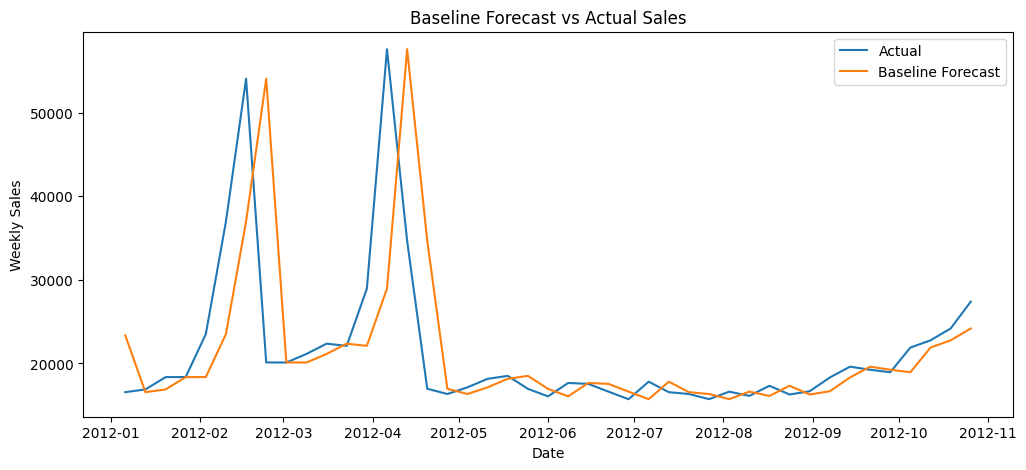

In [45]:
sample = test_df[
    (test_df["Store"] == 1) &
    (test_df["Dept"] == 1)
].copy()

plt.figure(figsize=(12,5))

plt.plot(
    sample["Date"],
    sample["Weekly_Sales"],
    label="Actual"
)

plt.plot(
    sample["Date"],
    sample["Lag_1"],
    label="Baseline Forecast"
)

plt.title("Baseline Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.show()

### Why Start with a Baseline?

A baseline provides a simple reference point for evaluating more sophisticated models.

If a machine learning model cannot outperform a naive forecast such as using last week's sales, the added complexity may not be justified.

Establishing a baseline is a common practice in forecasting because it helps quantify the value of the model beyond simple historical patterns.

### Train the Forecasting Model

With our features prepared and a baseline established, we're ready to train a machine learning model.

We'll use **LightGBM**, a gradient boosting algorithm that performs exceptionally well on structured and tabular data. It can capture complex, non-linear relationships while efficiently handling a large number of features.

After training the model, we'll compare its predictions against the baseline forecast.

In [46]:
# ============================================================
# Train LightGBM Model
# ============================================================

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4360
[LightGBM] [Info] Number of data points in the train set: 136342, number of used features: 27
[LightGBM] [Info] Start training from score 16729.243087


,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [47]:
# Generate predictions

predictions = model.predict(X_test)

In [51]:
test_results = test_df.copy()
test_results["Prediction"] = predictions

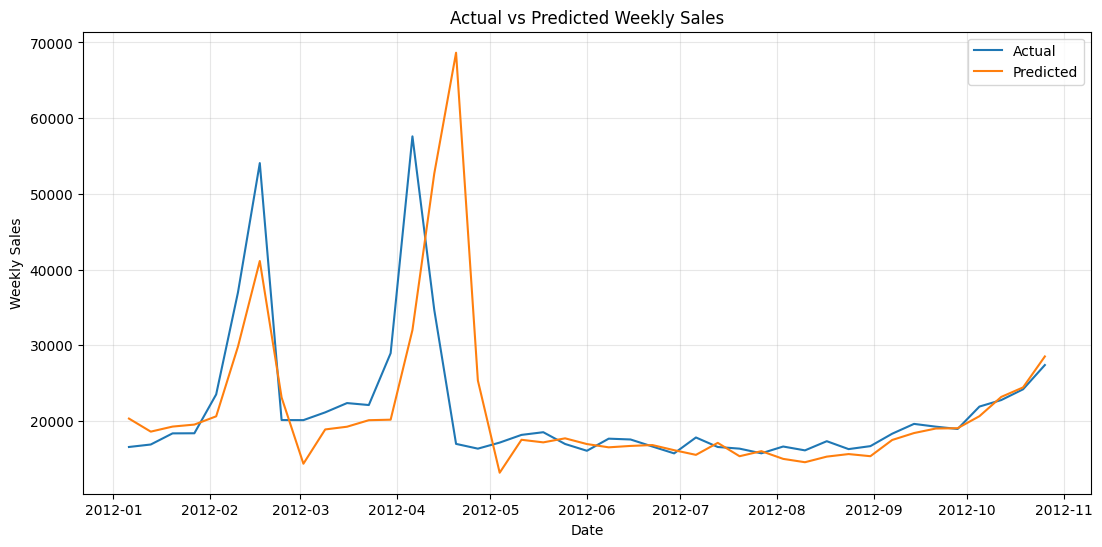

In [52]:
sample = test_results[
    (test_results["Store"] == 1) &
    (test_results["Dept"] == 1)
]

plt.figure(figsize=(13,6))

plt.plot(sample["Date"], sample["Weekly_Sales"], label="Actual")
plt.plot(sample["Date"], sample["Prediction"], label="Predicted")

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [48]:
# ============================================================
# Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"LightGBM MAE : {mae:,.2f}")
print(f"LightGBM RMSE: {rmse:,.2f}")

LightGBM MAE : 1,460.40
LightGBM RMSE: 3,233.57


In [49]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "LightGBM"],
    "MAE": [baseline_mae, mae],
    "RMSE": [baseline_rmse, rmse]
})

comparison

,Model,MAE,RMSE
0,Baseline,1751.047274,3982.258910
1,LightGBM,1460.403505,3233.568967


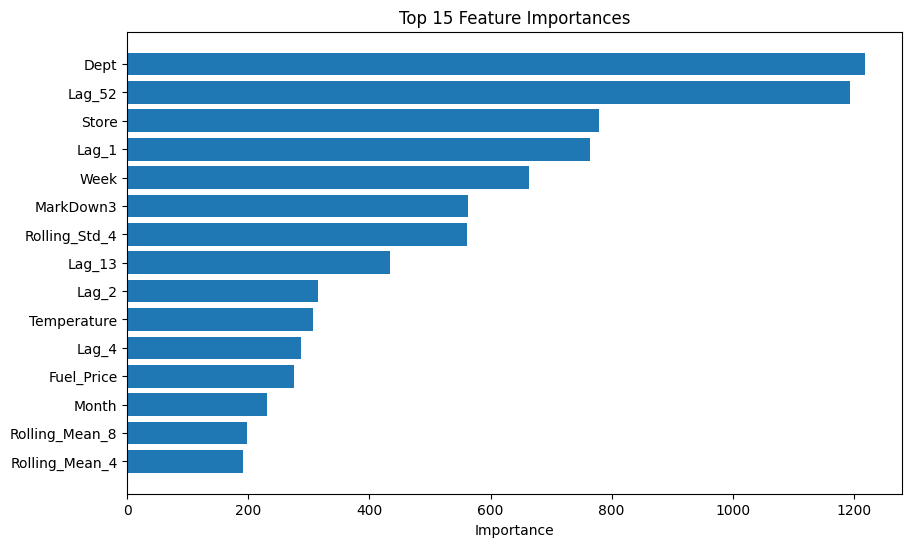

In [53]:
feature_importance = (
    pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

Historical sales patterns are the strongest predictors of future demand. Features such as the previous year's sales (Lag_52), the previous week's sales (Lag_1), and the calendar week contribute substantially to the model's performance. External variables, including temperature and fuel price, provide additional context but have a smaller influence compared with historical demand.

### Model Performance

The LightGBM model successfully captures historical sales patterns and outperforms the baseline forecast.

Feature importance shows that historical sales (lag features and rolling averages) are among the strongest predictors, while calendar and external variables provide additional context that helps explain fluctuations in demand.

Next, we'll examine where the model performs well, where it struggles, and what these results mean for real-world forecasting applications.

### Error Analysis

Evaluation metrics provide an overall measure of model performance, but they don't explain where the model succeeds or struggles.

In this section, we'll analyze the forecast errors to identify patterns that can guide future improvements.

In [55]:
# ============================================================
# Prediction Errors
# ============================================================

test_results["Error"] = (
    test_results["Weekly_Sales"] -
    test_results["Prediction"]
)

test_results["Absolute_Error"] = (
    test_results["Error"].abs()
)

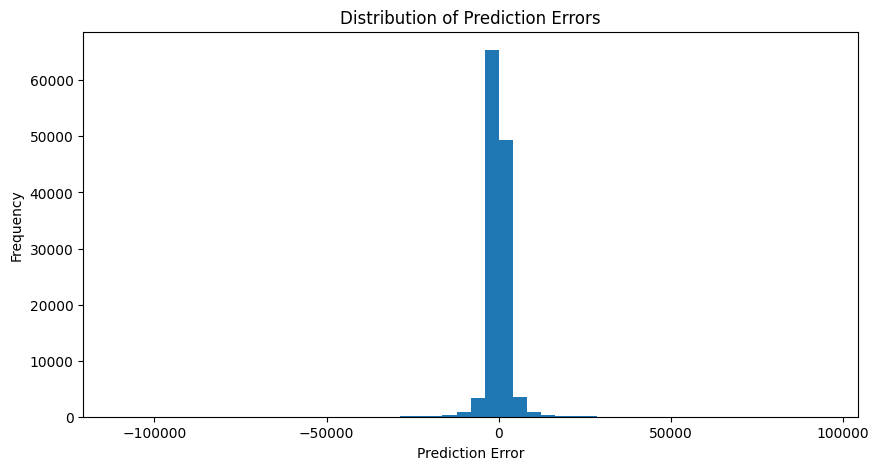

In [56]:
plt.figure(figsize=(10,5))

plt.hist(
    test_results["Error"],
    bins=50
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

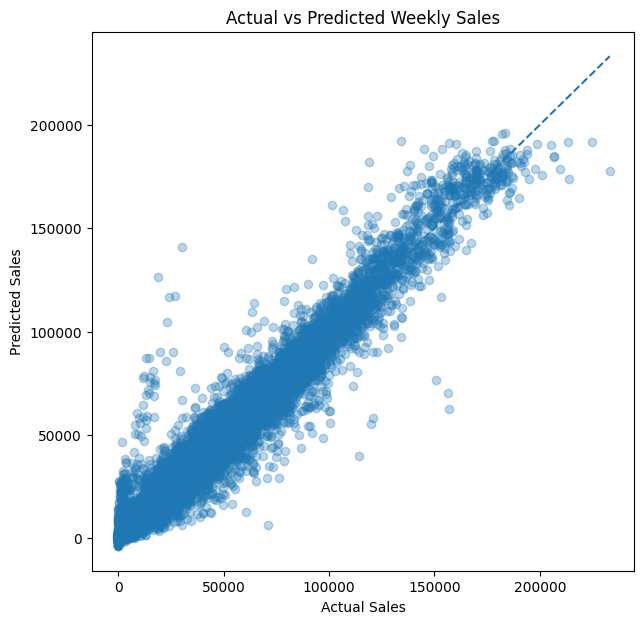

In [57]:
plt.figure(figsize=(7,7))

plt.scatter(
    test_results["Weekly_Sales"],
    test_results["Prediction"],
    alpha=0.3
)

plt.plot(
    [
        test_results["Weekly_Sales"].min(),
        test_results["Weekly_Sales"].max()
    ],
    [
        test_results["Weekly_Sales"].min(),
        test_results["Weekly_Sales"].max()
    ],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales")

plt.show()

The predicted values closely follow the actual sales, demonstrating that the model captures the overall sales patterns effectively. However, prediction errors become more pronounced as sales increase. This suggests that forecasting periods with exceptionally high demand remains more challenging than predicting typical sales levels.

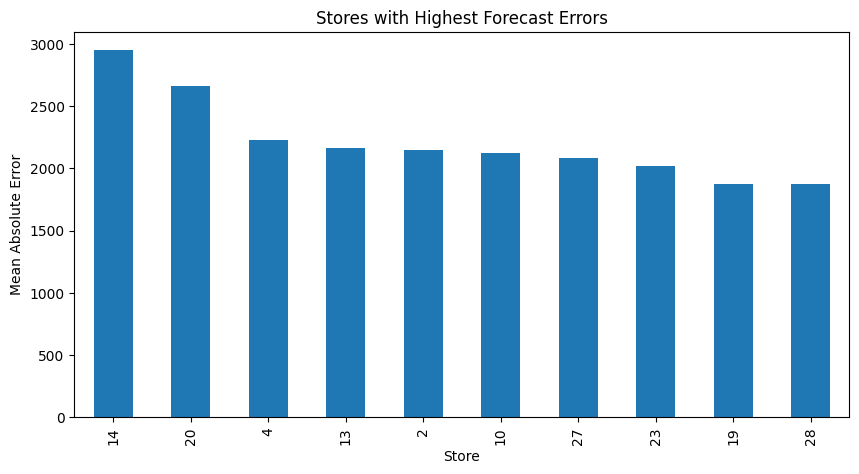

In [58]:
store_error = (
    test_results
    .groupby("Store")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

store_error.plot(kind="bar")

plt.ylabel("Mean Absolute Error")
plt.title("Stores with Highest Forecast Errors")

plt.show()

In [59]:
holiday_error = (
    test_results
    .groupby("IsHoliday")["Absolute_Error"]
    .mean()
)

holiday_error

IsHoliday
False    1457.435250
True     1521.196742
Name: Absolute_Error, dtype: float64

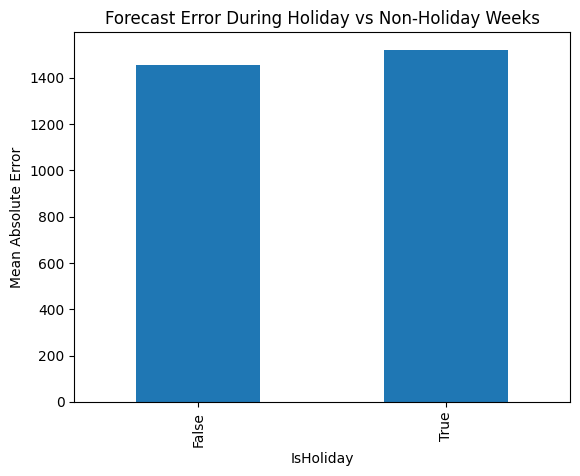

In [60]:
holiday_error.plot(kind="bar")

plt.ylabel("Mean Absolute Error")
plt.title("Forecast Error During Holiday vs Non-Holiday Weeks")

plt.show()

Forecast errors are slightly higher during holiday weeks than during non-holiday periods. Although the difference is relatively small, it suggests that holidays introduce additional variability into customer demand. Including holiday indicators helped the model account for much of this effect, but forecasting these periods remains inherently more difficult than typical weeks.

In [61]:
test_results.nlargest(
    10,
    "Absolute_Error"
)[[
    "Date",
    "Store",
    "Dept",
    "Weekly_Sales",
    "Prediction",
    "Absolute_Error"
]]

,Date,Store,Dept,Weekly_Sales,Prediction,Absolute_Error
73238,2012-04-20,13,1,30200.67,140689.982716,110489.312716
79801,2012-04-20,14,1,18877.13,126436.457458,107559.327458
79799,2012-04-06,14,1,156677.00,62398.470529,94278.529471
116544,2012-04-20,20,1,24247.26,116781.728313,92534.468313
54479,2012-04-20,10,1,26759.76,117316.461143,90556.701143
116542,2012-04-06,20,1,156234.28,70235.455323,85998.824677
134919,2012-04-20,23,1,23002.88,104419.926420,81417.046420
73440,2012-09-07,13,3,114230.60,39795.854861,74434.745139
128902,2012-04-20,22,1,12955.26,87215.366306,74260.106306
73236,2012-04-06,13,1,150715.44,76589.243211,74126.196789


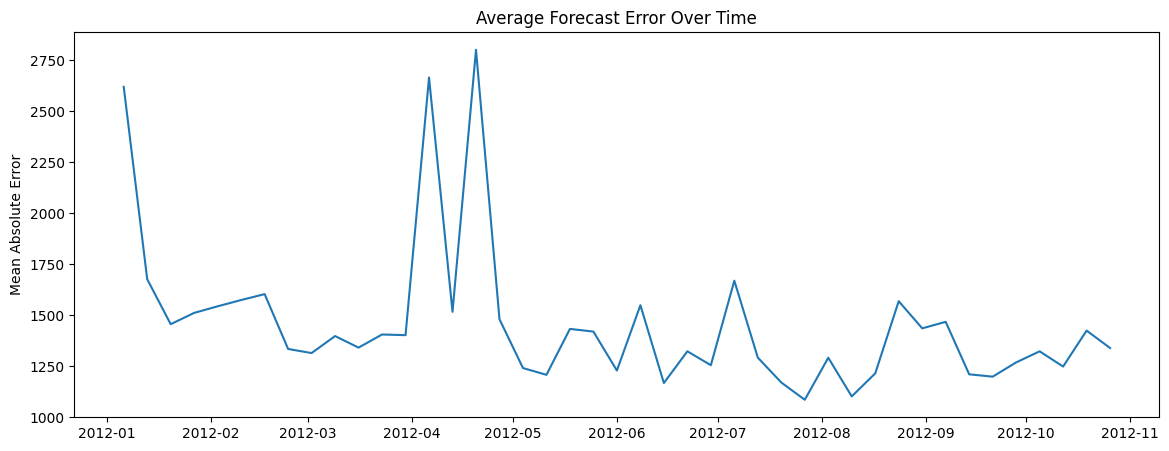

In [66]:
weekly_error = (
    test_results
    .groupby("Date")["Absolute_Error"]
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(weekly_error)

plt.title("Average Forecast Error Over Time")
plt.ylabel("Mean Absolute Error")

plt.show()

Forecast accuracy remains relatively stable throughout most of the year. However, several weeks experience noticeably higher prediction errors, indicating periods of unusual demand. These spikes suggest that certain business events or seasonal patterns are more difficult for the model to capture and may benefit from additional features or specialized forecasting strategies.

### Key Takeaways

The model performs well overall but struggles during periods of unusually high demand, particularly around major holidays and promotional events.

These errors suggest that while historical sales patterns explain much of the variation, additional business context—such as detailed promotion schedules or more granular holiday features—could further improve forecast accuracy.

Error analysis is an essential part of forecasting because it helps identify where the model can be refined before deployment.

<Axes: xlabel='IsHoliday'>

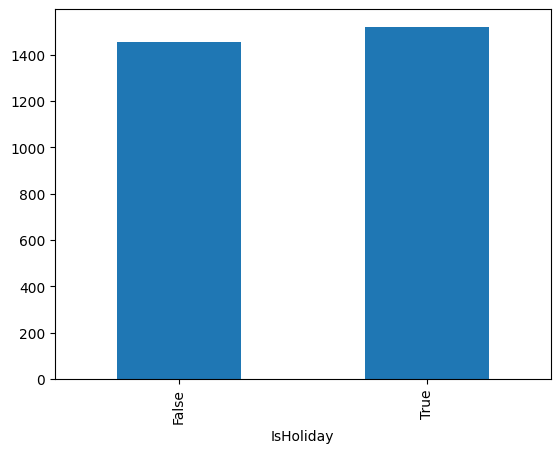

In [65]:
holiday_error = (
    test_results
    .groupby("IsHoliday")["Absolute_Error"]
    .mean()
)

holiday_error.plot(kind="bar")